
# Welcome to **Chroma&Co.py** 🧪
#### *Your Chromatography Assistant*

## Introduction

Chromatography is an essential analytical tool in modern laboratories, used daily to separate, identify, and quantify the components of complex mixtures with high precision. Whether you are a quality control technician in a pharmaceutical lab or a researcher analyzing environmental samples, the data generated by High-Performance Liquid Chromatography (HPLC) or Gas Chromatography (GC) is only as valuable as the calculations you can derive from it.

But have you ever run a chromatography experiment and found yourself bogged down by tedious manual calculations? How do you determine the true efficiency of your column? How do you predict the elution order of a new mixture before running the sample? And once you have a peak, how do you calculate its net retention time or the exact Kovats index to identify an unknown compound?

Meet **Chroma&Co.py**, a Python-based package toolkit designed to bridge the gap between chromatography theory and practical laboratory analysis by automating complex calculations for HPLC and Gas Chromatography. Its primary function is to eliminate manual calculation errors and streamline the interpretation of chromatographic data for separation efficiency and resolution. Simply input your retention times, peak widths, and column parameters, and the tool will instantly provide:

*   **Elution Order Predictions:** Anticipate the sequence of separation using LogP or dipole moment data for both polar and apolar columns.
*   **Efficiency Metrics:** Calculate the number of theoretical plates ($N$) and the Height Equivalent to a Theoretical Plate ($H$) to assess column performance.
*   **Resolution Analysis:** Determine if two peaks are fully separated ($R_S \ge 1.5$) or if co-elution is occurring.
*   **Quantitative Analysis:** Derive unknown concentrations using the standard addition method and calibration curves.
*   **Advanced Identification:** Compute net retention times and the Kovats Retention Index for compound identification against n-alkane standards.
*   **Column Comparison:** Objectively evaluate and score two different columns based on resolution, efficiency, and analysis time.

Unlock the full potential of your chromatographic data — from raw peak detection to advanced theoretical modeling.

The main chemistry involved in this work stems from **analytical chemistry** and **physical chemistry**, with a particular emphasis on separation efficiency, thermodynamic equilibrium, and the kinetics of solute migration. A core part of the modeling relies on established chromatographic formulae that relate retention behavior to column geometry and molecular properties.

The number of theoretical plates ($N$), a measure of column efficiency, is calculated as:

$$ N(J) = 16 \times \left( \frac{t_R(J)}{w(J)} \right)^2 $$

Where $N(J)$ is the number of theoretical plates for solute $J$, $t_R(J)$ is the gross retention time, and $w(J)$ is the peak width at the base.

The Height Equivalent to a Theoretical Plate ($H$), which represents the length of column required for one theoretical plate, is derived as:

$$ H(J) = \frac{L}{N(J)} $$

Where $L$ is the total length of the chromatography column. A smaller $H$ indicates a more efficient column.

The resolution ($R_S$) between two peaks, which determines the quality of the separation, is expressed as:

$$ R_S(1,2) = \frac{t_R(2) - t_R(1)}{\frac{1}{2} \times (w(1) + w(2))} $$

Where $t_R$ represents the retention time and $w$ the base width of the respective peaks. A resolution of $1.5$ or greater indicates baseline separation.

Finally, the identification of unknown compounds often relies on the **Kovats Retention Index**, calculated using the Van den Dool and Kratz equation:

$$ I = 100 \times \left[ n + \frac{\log(t'_R(x)) - \log(t'_R(n))}{\log(t'_R(N)) - \log(t'_R(n))} \right] $$

Where $n$ and $N$ are the carbon numbers of the n-alkanes eluting immediately before and after the unknown compound, and $t'_R$ represents the net retention time.


## 🧰 Material and methods

### 🗂 Data Sources 
Molecular property data were retrieved from two distinct public repositories to ensure comprehensive coverage for elution order predictions. Dipole moments were sourced from the Computational Chemistry Comparison and Benchmark Database (CCCBDB), maintained by the National Institute of Standards and Technology (NIST). This database provided experimentally derived and high-level calculated dipole values for a wide range of organic compounds.

LogP (octanol-water partition coefficient) values were obtained from the Virtual Computational Chemistry Laboratory (VCCLAB) ALogPS server. This resource offers predicted LogP values based on the ALogPS algorithm, which correlates molecular structure with hydrophobicity, serving as a critical parameter for estimating retention behavior in chromatographic systems.

All reference data, including n-alkane retention times used for dead time and Kovats index calculations, were compiled from standard analytical chemistry literature and manual calibration experiments, stored in structured CSV files within the project's data directory.

### 𝌤 Package Structure 
The **Chroma&Co.py** package was implemented in Python following a modular architecture organized under the `chromaco` namespace. The structure separates user-facing interfaces from core prediction algorithms to ensure scalability and maintainability:

*   **`chromaco/interfaces/`**: Contains the user interaction modules that handle input validation and result formatting for specific calculations. This includes:
    *   `interface_elut_ord.py`: Manages elution order prediction inputs.
    *   `interface_resolution_two_peaks.py`: Handles resolution calculations between two peaks.
    *   `interface_nb_de_plateau.py`: Manages theoretical plate ($N$) calculations.
    *   `interface_hauteur_equivalente.py`: Handles Height Equivalent to a Theoretical Plate ($H$) computations.
    *   `interface_standard_addition.py`: Manages standard addition and calibration curve inputs.
    *   `interface_retfac.py`: Handles retention factor ($k$) calculations.
    *   `interface_comparaison.py`: Provides the interface for advanced column comparison metrics.
    *   `interface_entree.py`: Centralized entry point for data validation.
    *   `interface_selectfact.py`: Handles the chromatographic selectivity factor (α) between two peaks calculations.
    *   `interface_kovats.py`: Performs Kovats chromatography calculations, including dead-time estimation using the Kovats triplet method and Kovats retention index determination via Van den Dool & Kratz interpolation.
*   **`chromaco/predictions/`**: Contains the core algorithmic logic for molecular property predictions:
    *   `logprd.py`: Implements the LogP-based elution prediction logic.
    *   `dipoleprd.py`: Implements the dipole moment-based elution prediction logic.
*   **`chromaco/__init__.py`**: Package initialization file that exports the main functions and modules for external use.

The project documentation is generated using **Sphinx** and stored in the `docs/` directory, while configuration and testing are managed via `pyproject.toml` for dependency handling, `tox.ini` for automated testing environments, and `.github/test.yaml` for continuous integration workflows.



## Results & Discussion

#### 🙌 **Functions in `chromaco/predictions/`**

One of the main purpose of this package is to provide the core computational engines for predicting molecular properties essential for chromatographic modeling. These modules implement physics-based and data-driven algorithms to estimate dipole moments and correct LogP values, transforming raw SMILES strings into actionable parameters for elution order prediction.

⚡ **Dipole Moment Estimation (`dipoleprd.py`)**
The `dipole_rdkit()` function estimates the molecular dipole moment using a custom physics model implemented with **RDKit**. It generates a 3D conformer for the input SMILES, calculates the center of mass, and computes a raw dipole by summing contributions from all bonds. Each bond's contribution is defined as the product of the Pauling electronegativity difference between atoms and the distance of the bond midpoint from the center of mass. The result is normalized by the molecule's maximum interatomic distance to provide a comparable index. This method relies on a comprehensive table of Pauling electronegativities for over 80 elements.


In [ ]:
from chromaco.predictions.dipoleprd import dipole_rdkit
smiles = "CCO" # Ethanol
dipole_val = dipole_rdkit(smiles)
print(f"Estimated dipole moment for {smiles} : {dipole_val:.4f}")

Estimated dipole moment for CCO : 1.2594


📊 **LogP Correction (`logpprd.py`)**
The `logp_correction()` function refines the estimation of LogP (octanol-water partition coefficient) by applying a linear regression correction to standard RDKit Crippen LogP calculations.
*   **Data-Driven Calibration:** The `compute_regression()` function analyzes a local calibration dataset (`data/logP.csv`), comparing experimental LogP values against RDKit predictions to derive correction coefficients ($a$ and $b$).
*   **Correction Formula:** The final corrected LogP is calculated as: $\text{LogP}_{corrected} = a \times \text{LogP}_{RDKit} + b$.
*   **Efficiency:** These coefficients are computed once upon module import, allowing for rapid, corrected LogP estimation for any valid SMILES string without repeated file parsing.

In [211]:
from chromaco.predictions.logpprd import logp_correction
smiles = "CCO" # Ethanol
logp_val = logp_correction(smiles)
print(f"LogP corrected for {smiles} : {logp_val:.4f}")

LogP corrected for CCO : -0.5284


Together, these modules enable **Chroma&Co.py** to handle molecules that may not be present in static lookup tables by generating their properties on the fly, significantly expanding the range of compounds that can be analyzed for elution order.

#### 🙌 **Functions in `chromaco/interfaces/fonctions_colonnes.py`**

One of the main purpose of this package is to serve as the central hub for chromatographic data processing, bridging the gap between raw experimental inputs and advanced analytical results. The functions in this module orchestrate the entire workflow, ranging from molecular database integration and elution prediction to the calculation of key efficiency metrics and the simulation of complex separation processes.

##### **Roles**

📂 **Database Integration & Elution Prediction**
The module begins with functions to load and manage external molecular datasets, including `load_logp_db()` and `load_dipole_db()`, which import LogP and dipole moment data from CSV files into structured dictionaries. These are utilized by `sort_by_logp()` and `sort_by_dipole()` to predict the elution order of compounds based on column polarity (polar vs. apolar), applying specific sorting rules and tie-breaking mechanisms to ensure deterministic results.

⚖️ **Efficiency & Resolution Metrics**
Core analytical capabilities are provided by functions that calculate fundamental chromatographic parameters. `theorical_plates_one()` and `equivalent_high_one()` compute the number of theoretical plates ($N$) and the Height Equivalent to a Theoretical Plate ($H$) to assess column efficiency. Meanwhile, `resolution_between_two_peaks()` and `calculate_resolution_from_dict()` determine the separation quality ($R_S$) between individual or multiple peak pairs, validating that peaks are fully resolved ($R_S \ge 1.5$).

⏱️ **Advanced Quantitative Analysis**
The module extends to complex quantitative tasks, including `calculate_dead_time_kovats()`, which estimates the dead time ($t_M$) using the Kovats method with n-alkane references. It also features `calculate_net_retention_times()` to correct gross retention times, `calculate_retention_factor()` for determining retention factors ($k$), and `calculate_kovats_index()` for identifying unknown compounds via the Van den Dool and Kratz equation.

📊 **Visualization & Simulation**
For deeper insights, the module includes `plot_standard_addition()`, which performs linear regression on calibration data to determine unknown concentrations and generates visual plots. It also houses `craig_battery_simulation()`, a powerful tool for modeling the Craig Counter-Current Distribution process, allowing users to visualize the theoretical separation of compounds across multiple extraction stages.

🔍 **Comparative Analysis**
Finally, the module provides `compare_two_columns_advanced()`, a comprehensive function that evaluates two different columns against multiple metrics (resolution, efficiency, analysis time) to generate a comparative verdict, including automatic warnings for any separation failures below the baseline threshold.

##### **Functions description**

🧪 **Theoretical Plates Calculation**
The function `theorical_plates_one()` calculates the number of theoretical plates ($N$) for a chromatography column, a key indicator of column efficiency. It requires the gross retention time ($t_R$) and the peak width at the base ($w$). The function implements the formula $N = 16 \times (t_R / w)^2$ and includes robust error handling to prevent division by zero or negative inputs, ensuring only physically possible values are processed.

In [212]:
from chromaco.interfaces.fonctions_colonnes import theorical_plates_one
N = theorical_plates_one(brut_retention_time=5.2, peak_width=0.15)
print(f"Number of theoretical plates : {N:.2f}")

Number of theoretical plates : 19228.44


⚖️ **Column Efficiency (HETP)**
The function `equivalent_high_one()` determines the Height Equivalent to a Theoretical Plate (HETP), which represents the length of column required for one theoretical plate. By combining the column length with the theoretical plate count (calculated via `theorical_plates_one()`), it provides a standardized measure of column performance. A lower HETP value indicates a more efficient column, and the result is rounded to seven decimal places for precision.


In [213]:
from chromaco.interfaces.fonctions_colonnes import equivalent_high_one
H = equivalent_high_one(column_length=150, brut_rentention_time=5.2, peak_width=0.15)
print(f"Equivalent height (HETP) : {H:.6f} mm")

Equivalent height (HETP) : 0.007801 mm


📈 **Resolution Between Peaks**
The function `resolution_between_two_peaks()` calculates the resolution ($R_S$) between two consecutive chromatographic peaks to determine if a separation is complete. It uses the retention times and base widths of both peaks. If the resulting $R_S$ is greater than or equal to 1.5, the separation is considered baseline resolved. The function strictly validates that the second peak elutes after the first and that all width and time values are positive.

In [214]:
from chromaco.interfaces.fonctions_colonnes import resolution_between_two_peaks
Rs = resolution_between_two_peaks(brut_retention_time_1=5.0, brut_retention_time_2=5.5, peak_width_1=0.1, peak_width_2=0.12)
print(f"Resolution (Rs) : {Rs:.3f}")

Resolution (Rs) : 4.545


📊 **Batch Resolution Analysis**
For users working with multiple peaks, `calculate_resolution_from_dict()` streamlines the process by accepting a dictionary of peak data (retention time and width) indexed by integers. It automatically identifies consecutive peaks (n and n+1), validates the data structure, and calculates the resolution between them. This function raises specific errors if the index is missing, data dimensions are incorrect, or if the elution order is logically inconsistent.


In [215]:
from chromaco.interfaces.fonctions_colonnes import calculate_resolution_from_dict
peaks_data = {1: [5.0, 0.1], 2: [5.5, 0.12], 3: [6.2, 0.15]}
Rs_batch = calculate_resolution_from_dict(peaks_data=peaks_data, index_n=1)
print(f"Resolution between peaks 1 and 2 : {Rs_batch:.3f}")

Resolution between peaks 1 and 2 : 4.545


⏱️ **Dead Time Determination (Kovats Method)**
The function `calculate_dead_time_kovats()` estimates the dead time ($t_M$) of the column using the Kovats method. It requires retention times from at least three consecutive n-alkanes. The algorithm iterates through all valid triplets to calculate $t_M$ individually, filtering out invalid mathematical results (such as division by zero or negative dead times), and returns the average of the valid calculations. This ensures a reliable baseline for calculating retention factors in complex mixtures.

In [216]:
from chromaco.interfaces.fonctions_colonnes import calculate_dead_time_kovats
alkane_data = {10: 8.5, 11: 10.2, 12: 12.4}
t_dead = calculate_dead_time_kovats(retention_times=alkane_data)
print(f"Dead time (tM) : {t_dead:.4f} min")

Dead time (tM) : 2.7200 min


📂 **Database Loading**
The functions `load_logp_db()` and `load_dipole_db()` are responsible for importing molecular data from CSV files. `load_logp_db()` reads LogP values indexed by both CAS numbers and SMILES strings, while `load_dipole_db()` loads dipole moments indexed by SMILES. Both functions perform rigorous validation to ensure required columns exist, values are numeric, and the data is not empty, raising specific errors if the file format is incorrect or data is missing.

🔢 **Elution Sorting by LogP**
The function `sort_by_logp()` predicts elution order by sorting molecules based on their LogP values. It applies different sorting rules depending on the column type: for an **apolar column**, it sorts in ascending LogP (least polar elutes first), whereas for a **polar column**, it sorts in descending LogP (most polar elutes first). The function includes a tie-breaking mechanism using the length of the SMILES string to ensure a deterministic order and validates that all input molecules exist in the database.

In [ ]:
from chromaco.interfaces.fonctions_colonnes import load_logp_db, sort_by_logp
db_logp = load_logp_db(path="data/logP.csv")
molecules = ["C1CCCN1", "Oc1ccncc1", "CC=CC=O"]
elution_order = sort_by_logp(molecules=molecules, db=db_logp, column_type="apolar")
print(f"Elution order (Apolar) : {elution_order}")

Elution order (Apolar) : ['CC=CC=O', 'Oc1ccncc1', 'C1CCCN1']


⚡ **Elution Sorting by Dipole**
The function `sort_by_dipole()` performs a similar prediction using dipole moments instead of LogP. It follows the same logic: ascending dipole for apolar columns and descending dipole for polar columns. The function also implements a tie-breaker based on the length of the molecular formula string. It strictly checks for valid column types and ensures that every molecule provided by the user is present in the dipole database before returning the sorted list.

In [ ]:
from chromaco.interfaces.fonctions_colonnes import load_dipole_db, sort_by_dipole
db_dipole = load_dipole_db(path="/data/dipole.csv")
molecules = ["[H][H]", "ClC(Cl)C(Cl)Cl", "CC(Cl)Cl"]
elution_order_dipole = sort_by_dipole(molecules=molecules, db=db_dipole, column_type="polar")
print(f"Elution order (Polar) : {elution_order_dipole}")

Elution order (Polar) : ['CC(Cl)Cl', 'ClC(Cl)C(Cl)Cl', '[H][H]']


📊 **Standard Addition Analysis**
The function `plot_standard_addition()` accepts two lists of numeric values: the added concentrations and their corresponding peak areas. It validates that both lists are of equal length and contain at least two data points. Using NumPy, it performs a linear regression to determine the slope ($a$) and intercept ($b$) of the best-fit line. The function includes a safety check to ensure the slope is not zero, which would make the calculation impossible.


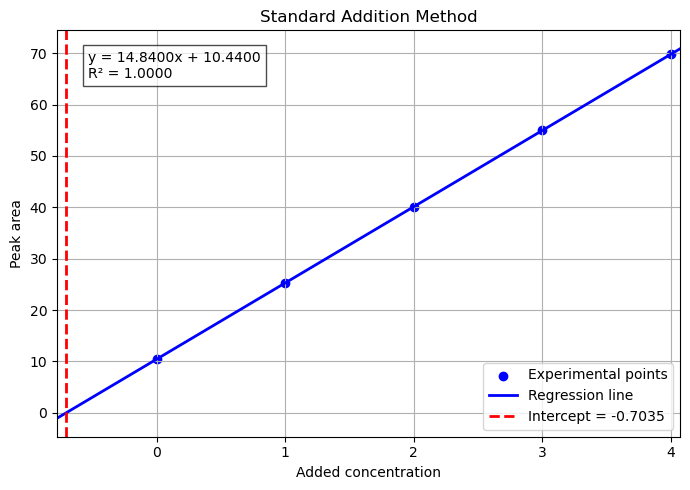

Unkown Concentration : -0.7035


In [219]:
from chromaco.interfaces.fonctions_colonnes import plot_standard_addition
concentrations = [0.0, 1.0, 2.0, 3.0, 4.0]
areas = [10.5, 25.2, 40.1, 55.0, 69.8]
results = plot_standard_addition(concentrations=concentrations, areas=areas, show_plot=True)
print(f"Unkown Concentration : {results['C_unknown']:.4f}")

📉 **Concentration Calculation & Visualization**
From the regression parameters, the function calculates the unknown concentration ($C_{unknown}$) by finding the x-intercept of the line (where $y=0$). It also computes the coefficient of determination ($R^2$) to indicate the quality of the fit. If `show_plot` is enabled, the function generates a scatter plot of the experimental points, the regression line, and a vertical dashed line marking the intercept. The plot includes the regression equation and $R^2$ value for immediate interpretation. The function returns a dictionary containing the slope, intercept, $R^2$, and the calculated unknown concentration.

🧪 **Net Retention Times**
The function `calculate_net_retention_times()` computes the net retention time ($t_R'$) for a list of peaks by subtracting the dead time ($t_M$) from the gross retention times. It relies on the previously defined `calculate_dead_time_kovats()` function to derive the dead time from a reference dataset of n-alkanes. The function includes a validation step that raises an error if the alkane data is insufficient or inconsistent, and it issues a warning if any peak elutes before the dead time, indicating an unretained artifact.

In [220]:
from chromaco.interfaces.fonctions_colonnes import calculate_net_retention_times
gross_times = [5.2, 6.8, 8.5]
alkane_refs = {10: 8.5, 11: 10.2, 12: 12.4}
net_times = calculate_net_retention_times(all_retention_times=gross_times, alkane_data=alkane_refs)
print(f"Net retention times : {net_times}")

Net retention times : [2.479999999999973, 4.0799999999999725, 5.779999999999973]


⚖️ **Selectivity Factor**
The function `calculate_selectivity_factor()` determines the selectivity factor ($\alpha$) between two peaks, which expresses the relative retention of two analytes. It calculates the retention factors ($k$) for both peaks using the dead time and returns the ratio of the larger $k$ to the smaller one, ensuring that $\alpha \ge 1$. This metric is crucial for assessing the ability of a column to distinguish between two specific compounds.

In [221]:
from chromaco.interfaces.fonctions_colonnes import calculate_selectivity_factor
alpha = calculate_selectivity_factor(t_r1=5.2, t_r2=6.8, t_0=1.5)
print(f"Selectivity factor (α) : {alpha:.4f}")

Selectivity factor (α) : 1.4324


⚗️ **Craig Battery Simulation**
The function `craig_battery_simulation()` models the Craig Counter-Current Distribution process, a theoretical method used to simulate the separation of components in a multi-stage extraction. It takes the number of tubes, transfer steps, and partition coefficients ($K$) for each compound as input. The function iteratively calculates the distribution of mass between mobile and stationary phases across the tubes. It offers an optional visualization mode that prints a summary of peak positions at regular intervals and can display a simplified ASCII profile of the distribution, allowing users to track the separation progress in real-time. The function returns a complete history of the distribution for all compounds.

In [222]:
from chromaco.interfaces.fonctions_colonnes import craig_battery_simulation
k_values = {"Fast": 0.5, "Slow": 2.0}
history = craig_battery_simulation(n_tubes=10, n_steps=10, k_values=k_values, visualize_step_by_step=True)
print(f"Simulation terminée. Forme du tableau : {history['Fast'].shape}")


Starting Simulation: 10 tubes, 10 steps.
Visualization interval: Every 5 steps.

Step | T 0 | T 1 | T 2 | T 3 | T 4 | T 5 | T 6 | T 7 | T 8 | T 9
----------------------------------------------------------------
   5 | Fast:3(0.33) | Slow:1(0.33) | 
   9 | Fast:6(0.27) | Slow:3(0.27) | 

Simulation Complete.
Simulation terminée. Forme du tableau : (10, 10)


🧪 **Kovats Retention Index**
The function `calculate_kovats_index()` determines the Kovats Retention Index ($I$) for an unknown compound using the Van den Dool and Kratz equation. It requires the gross retention time of the unknown, a list of all observed retention times, and reference data for n-alkanes. The function first calculates net retention times for all peaks to ensure consistency, then interpolates the index based on the logarithmic retention times of the bracketing alkanes. It strictly validates that the unknown elutes between the specified reference alkanes and raises errors for inconsistent elution orders or invalid data.

In [223]:
from chromaco.interfaces.fonctions_colonnes import calculate_kovats_index
unknown_time = 6.5
all_times = [5.0, 7.5, 9.0, 12.0]
alkane_data_kovats = {8: 4.2, 9: 5.0, 10: 6.0, 11: 7.0}
index = calculate_kovats_index(gross_retention_unknown=unknown_time, all_gross_times=all_times, alkane_data=alkane_data_kovats, n_carbon_before=10, n_carbon_after=11)
print(f"Kovats index : {index:.1f}")

Kovats index : 1052.3


⚖️ **Retention Factor Calculation**
The function `calculate_retention_factor()` computes the retention factor ($k$), a dimensionless parameter indicating how long an analyte is retained relative to an unretained compound. It applies the formula $k = (t_R - t_0) / t_0$ with rigorous input validation. The function checks for non-numeric values, ensures both retention time ($t_R$) and dead time ($t_0$) are strictly positive, and verifies that the analyte elutes after the dead time ($t_R > t_0$), preventing physical impossibilities.

In [224]:
from chromaco.interfaces.fonctions_colonnes import calculate_retention_factor

t_r = 8.5
t_0 = 1.2

k_value = calculate_retention_factor(t_r=t_r, t_0=t_0)

print(f"--- Retention Factor Calculation ---")
print(f"Retention Time (tR): {t_r} min")
print(f"Dead Time (t0):      {t_0} min")
print(f"Retention Factor (k): {k_value:.4f}")
print(f"Interpretation: The compound is retained {k_value:.1f} times longer than an unretained species.")

--- Retention Factor Calculation ---
Retention Time (tR): 8.5 min
Dead Time (t0):      1.2 min
Retention Factor (k): 6.0833
Interpretation: The compound is retained 6.1 times longer than an unretained species.


📊 **Advanced Column Comparison**
The function `compare_two_columns_advanced()` offers a comprehensive evaluation of two chromatographic columns (A and B). It calculates and aggregates key performance metrics including resolution ($R_S$), theoretical plates ($N$), height equivalent to a theoretical plate ($H$), and peak widths. The function supports both "global" comparison of all peaks or a "subset" mode for selected peaks. It implements an elimination rule where a column is flagged if any consecutive peak pair has a resolution below 1.5, and it generates specific warnings for such cases. The function returns a detailed dictionary containing scores, a verdict on which column is superior for specific criteria (efficiency, speed, resolution), and a list of any resolution failures.

In [225]:
from chromaco.interfaces.fonctions_colonnes import compare_two_columns_advanced
col_a = {1: [5.0, 0.1], 2: [6.0, 0.12], 3: [7.5, 0.15]}
col_b = {1: [5.1, 0.11], 2: [6.2, 0.13], 3: [7.6, 0.14]}
comparison = compare_two_columns_advanced(columnA=col_a, columnB=col_b, column_length=150.0, mode="global")
print(f"Verdict : {comparison['verdict']}")

Verdict : {'Best_resolution': 'A', 'Best_efficiency_N': 'A', 'Best_HETP': 'A', 'Best_peak_width': 'A', 'Fastest': 'A'}


### Limitations

The **Chroma&Co.py toolkit** operates with specific limitations regarding the precision of its predictive models, particularly for elution order. The package relies on two primary approximation methods; logP and dipole moments, which are not intended for high-precision quantitative forecasting but rather for qualitative guidance.

The **logP prediction** utilizes RDKit to retrieve logP values based on SMILES strings. However, this method carries a significant margin of error, potentially deviating by up to five orders of magnitude in certain complex cases. Similarly, the **dipole-based prediction** employs an approximation function that sums partial charges and calculates their distance to the center of mass, which simplifies the complex electrostatic interactions occurring within a chromatographic system.

It is also important to note that currently, the package relies on a curated dataset containing 468 dipole moments and 1,310 LogP values. This limitation means that elution order predictions are only possible for compounds present within these specific lists; any molecule not found in the database cannot be processed for order prediction and will trigger a validation error.

To ensure scientific integrity and transparency, the package automatically notifies the user which specific formula (logP or dipole) was applied to generate the result. Users should treat these predictions as preliminary estimates rather than definitive analytical data, especially when high accuracy is required for regulatory or critical research purposes.


## Improvements and Conclusion 
**Chroma&Co.py** provides a robust and practical toolkit for automating the complex calculations inherent in High-Performance Liquid Chromatography (HPLC) and Gas Chromatography (GC). By integrating standard chromatographic formulas with predictive algorithms for elution order, the package enables rapid assessment of column efficiency, separation resolution, and compound identification via the Kovats Index. It further extends utility by supporting quantitative analysis through standard addition methods and advanced simulations like the Craig Counter-Current Distribution, streamlining data interpretation for both routine analysis and theoretical modeling.

Throughout its development, key challenges such as the manual burden of repetitive calculations and the complexity of predicting elution sequences were successfully addressed through modular code design and the integration of external databases. While the tool presents a valuable foundation for analytical chemistry workflows, it is important to acknowledge its limitations; specifically the finite size of the reference databases (currently 468 dipole moments and 1,310 LogP values), the approximate nature of the prediction algorithms (which may deviate significantly for complex structures), and the reliance on user-provided peak data for resolution calculations.

To go further, one could expand the molecular databases by scraping additional sources or integrating real-time API queries to cover a broader range of analytes. The prediction models could also be refined by incorporating machine learning techniques trained on experimental retention data to reduce the approximation errors inherent in LogP and dipole summation methods. Furthermore, the package could be extended to handle automated batch processing of raw chromatographic files, eliminating the need for manual data entry entirely.

In conclusion, **Chroma&Co.py** offers a thoughtful blend of analytical chemistry principles and computational efficiency. It is best viewed as a powerful exploratory and validation tool that complements expert chromatographic knowledge and experimental rigor. It acts as a digital assistant for the chromatographer, transforming tedious arithmetic into instant insights. The future of chromatography looks precise, efficient, and fully automated.

## 📚 **References**

**Theoretical Foundations & General Chromatography**
Skoog, D.A., West, D.M., Holler, F.J. and Crouch, S.R. (2014) *Fundamentals of Analytical Chemistry*. 9th edn. Boston: Cengage Learning. Available at: https://www.cengage.com (Accessed: 23 May 2026).

Van den Dool, H. and Kratz, P.D. (1963) 'A generalization of the retention index system including linear temperature programmed gas-liquid partition chromatography', *Journal of Chromatography A*, 11(4), pp. 463–471. Available at: https://doi.org/10.1016/S0021-9673(01)80947-X (Accessed: 23 May 2026).

Kovats, E. (1958) 'Gaschromatographische charakterisierung organischer verbindungen. Teil 1: Ramen-Index aliphatischer halogene', *Helvetica Chimica Acta*, 41(7), pp. 1915–1932. Available at: https://doi.org/10.1002/hlca.19580410711 (Accessed: 18 May 2026).

Craig, C.L. (1949) 'Counter-current Distribution. I. A theory for the separation of complex mixtures', *Journal of the American Chemical Society*, 71(1), pp. 355–362. Available at: https://doi.org/10.1021/ja01169a060 (Accessed: 18 May 2026).

**Molecular Property Prediction (Dipole & LogP)**
RDKit Documentation (no date) *RDKit: Open-source cheminformatics*. Available at: https://www.rdkit.org/docs/ (Accessed: 15 May 2026).

Pauling, L. (1960) *The Nature of the Chemical Bond*. 3rd edn. Ithaca: Cornell University Press. Available at: https://www.cornell.edu/library (Accessed: 10 May 2026).

Ghose, A.K. and Crippen, G.M. (1987) 'Atomic physicochemical parameters for three-dimensional-structure-directed quantitative structure-activity relationships. 2. Modeling dispersive and hydrophobic interactions', *Journal of Computational Chemistry*, 8(1), pp. 36–51. Available at: https://doi.org/10.1002/jcc.540080106 (Accessed: 12 May 2026).

Ghose, A.K., Viswanadhan, V.N. and Wendoloski, J.J. (1998) 'A knowledge-based approach in designing combinatorial or medicinal chemistry libraries for drug discovery. 1. A qualitative and quantitative characterization of known drug databases', *Journal of Combinatorial Chemistry*, 1(1), pp. 55–68. Available at: https://doi.org/10.1021/cc980007i (Accessed: 22 May 2026).

**Data Sources**
Computational Chemistry Comparison and Benchmark Database (CCCBDB) | NIST (no date). Available at: https://cccbdb.nist.gov/diplistx.asp (Accessed: 4 May 2026).

Virtual Computational Chemistry Laboratory (VCCLAB) (no date) *ALogPS 2.1*. Available at: https://vcclab.org/lab/alogps/ (Accessed: 4 May 2026).

Teledyne Technologies (no date) *Gas Chromatography*. Available at: https://www.teledynelabs.com/products/chromatography/gc-prep/gas-chromatography (Accessed: 6 May 2026).

C. Roussel, S. Thonney, F. Gumy, “Chromatographie en phase gazeuse”, EPFL, spring 2026.

C. Roussel, “Chromatographie”, course, EPFL, spring 2026.

C. Roussel, “Analyse quantitative”, EPFL, year 2024-2025.

Méthode de séparation analytique, Chromatographie HPLC, Roussel C.